# Band structure and DOS for Si

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

Ref:
    https://wiki.fysik.dtu.dk/ase/ase/dft/kpoints.html

## Imports

NumPy, QEpy's `QEpyCalculator`/`QEInput`, ASE utilities for building the silicon structure and plotting, and DFTpy's `download_files` helper for fetching the pseudopotential.

In [1]:
import numpy as np
from qepy.calculator import QEpyCalculator
from qepy.io import QEInput
from ase.io.trajectory import Trajectory
from ase.build import bulk
from ase import Atoms
import matplotlib.pyplot as plt
from dftpy.formats import download_files

## System: Si (silicon)

Bulk silicon (diamond structure), norm-conserving PZ pseudopotential, modest cutoffs and a 9×9×9 k-mesh for a quick ground-state run — refined later for the DOS/band-structure steps.

In [3]:
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'prefix': "'tmp'",
        'pseudo_dir': "'./data/'"},
    '&system': {
        'ibrav' : 0,
        'ecutwfc': 20,
        'ecutrho': 200},
    '&electrons': {
        'conv_thr' : 1.0e-8},
     'atomic_species': ['Si 28.085 Si.pz-vbc.UPF'],
     'k_points automatic': [' 9 9 9 0 0 0'],
}

## Build atoms and attach the QEpy calculator

Build the silicon lattice with ASE, then attach `QEpyCalculator` as its ASE calculator — subsequent ASE calls like `get_potential_energy()` transparently drive QE underneath.

In [5]:
atoms = bulk('Si', a=5.431)

In [6]:
calc = QEpyCalculator(qe_options=qe_options, logfile='tmp.out')
atoms.calc=calc

## Run a ground state calculation

In [7]:
energy = atoms.get_potential_energy()
efermi = calc.get_fermi_level()
print(efermi)

6.053474430208152


## DOS with a fine mesh of $k$-points $\in$ FBZ

In [8]:
qe_options['k_points automatic']= ['12 12 12 0 0 0']
energies, dos =  atoms.calc.get_dos(qe_options, width=0.6)

Text(-1.5, 1.5, 'Fermi level')

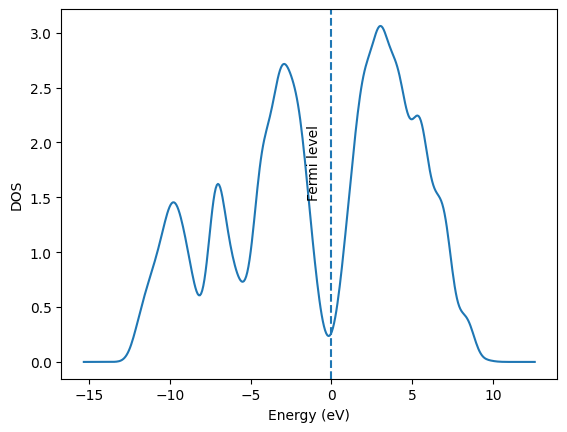

In [9]:
plt.plot(energies, dos)
plt.axvline(x=0, ls='--'); plt.xlabel("Energy (eV)"); plt.ylabel("DOS"); 
plt.text(x=-1.5,y=1.5,rotation='vertical',s='Fermi level')

## Band structure with ASE bandpath

First inspect the Brillouin zone and its high-symmetry point labels (needed to pick a sensible k-path below).

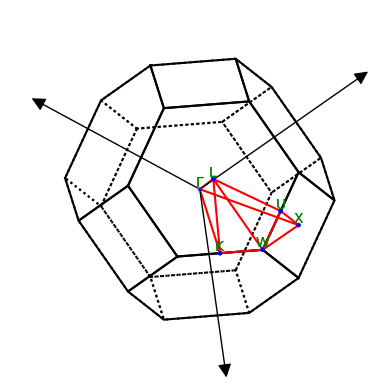

FCC(a=5.431)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



In [10]:
lat = atoms.cell.get_bravais_lattice()
lat.plot_bz(show=True)
print(lat.description())

In [11]:
path = atoms.cell.bandpath('LGXU,KG',npoints=61)

In [12]:
qe_options['&system']['nbnd']=8
band = atoms.calc.get_band_structure(qe_options, kpts=path, reference=efermi)
band = band.subtract_reference()

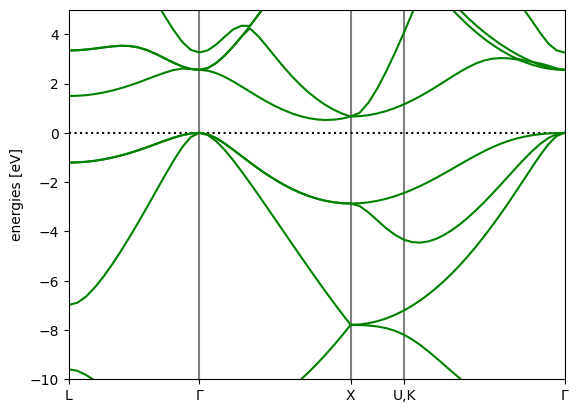

In [13]:
bp=band.plot()

## Combined band structure + DOS plot

A publication-style panel: bands on the left, DOS on the right, sharing the same energy axis.

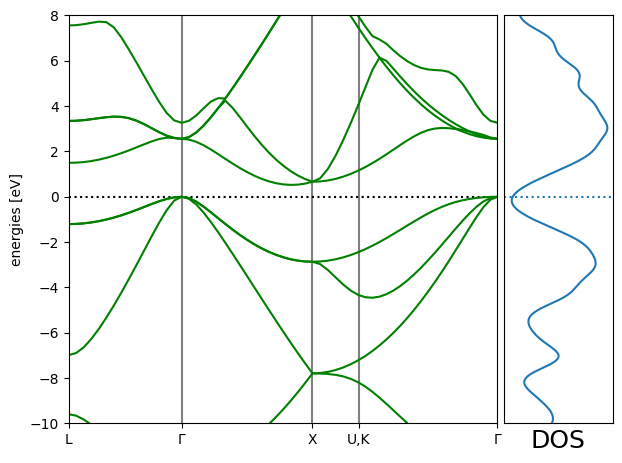

In [14]:
fig = plt.figure()
ax = fig.add_axes([.12, .07, .67, .85])

emin = -10.0; emax = 8.0

band.plot(ax=ax, emin=emin, emax=emax)

dosax = fig.add_axes([.8, .07, .17, .85])
dosax.plot(dos, energies)
dosax.axhline(y=0, ls=':')

dosax.set_ylim(emin, emax)
dosax.set_xlim(0, None)
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS", fontsize=18);